# MALARIA DETECTION

### Lets take a look at how we are gonna make our model

#### Step 1:  Loading and Splitting of the Dataset

- The first step is to load the data and scaling the images to binary 0 and 1 from Parasitized and Uninfected.
- Then we will resize the images to 50 x 50
- After that suffling of the images before train-test-split and converting the images to a single numpy array
- Splitting the data
- Converting the type of X_train and X_valid to float32
- Add then One Hot Encoding on y


#### Step 2:  Building the CNN model
- The CNN model is one of the efficient nueral networks for images and performing classifications. We will use tf.keras to build the CNN model.
- We will build a Sequential CNN model.
- We will build a CNN Layer followed by MaxPooling layer which is later followed by BatchNormalisation to normalize the previous layer's output and implement the Dropout regularization. After that we will use Flatten to the outputs. Then the last layer that has function Softmax is the output layer.
- Finally we have to compile the CNN model. We will use optimizer called Adam then will apply the loss function as categorical_crossentropy and an evaluation metric as accuracy.
- Next step is to use the fit function, to train our convolutional neural network (CNN) with X_train and y_train. Lets set the total amounts of epochs as 25 epochs, which is essentially 25 cycles or iterations of the full dataset including a batch size of 120.

####  Step 3 : Predictions and Testing of the Model
- After this we will predict and do evaluation on the builded model.
- The last step will be to test our model on the HOLDOUT DATASET and making predictions.

In [ ]:
# ============================================
# Install Kaggle API (Only if not already installed)
# ============================================

import importlib.util
import sys

if importlib.util.find_spec("kaggle") is None:
    print("📦 Kaggle API not found. Installing...")
    !{sys.executable} -m pip install -q kaggle
    print("✅ Kaggle API installed successfully.")
else:
    print("✅ Kaggle API is already installed.")

✅ Kaggle API is already installed.


In [ ]:
# ============================================
# Check if Kaggle API is Configured
# ============================================

import os

if os.path.exists("/root/.kaggle/kaggle.json"):
    print("✅ Kaggle API is already configured.")
else:
    print("❌ Kaggle API is NOT configured.")
    print("➡️ Next step: Add your kaggle.json file.")

❌ Kaggle API is NOT configured.
➡️ Next step: Add your kaggle.json file.


In [ ]:
# ============================================
# Configure Kaggle Access Token
# ============================================

import os

# Create the Kaggle configuration directory
os.makedirs("/root/.kaggle", exist_ok=True)

# Paste your Kaggle API token here
TOKEN = "KGAT_ea29fb566c7db7d6bfd1bb89bdf2ab29" # KGAT_ea29fb566c7db7d6bfd1bb89bdf2ab29

# Save the token where the Kaggle CLI expects it
with open("/root/.kaggle/access_token", "w") as f:
    f.write(TOKEN)

# Secure the token file
os.chmod("/root/.kaggle/access_token", 0o600)

print("✅ Kaggle Access Token configured successfully!")

✅ Kaggle Access Token configured successfully!


In [ ]:
# ============================================
# STEP 3: Verify Kaggle Authentication
# ============================================

import subprocess

print("🔍 Checking Kaggle authentication...")

result = subprocess.run(
    ["kaggle", "datasets", "list", "-s", "malaria"],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print("✅ Kaggle API connected successfully!")
    print("\n📂 Sample search results:\n")
    print(result.stdout)
else:
    print("❌ Kaggle API is not connected.")
    print("\nError details:")
    print(result.stderr)

🔍 Checking Kaggle authentication...
✅ Kaggle API connected successfully!

📂 Sample search results:

ref                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
imdevskp/malaria-dataset                            Malaria Dataset                                          53674  2020-07-01 17:28:22.467000          12433        159                1  
iarunava/cell-images-for-detecting-malaria          Malaria Cell Images Dataset                          708172590  2018-12-05 05:40:21.920000          82567       1345            0.625  
lydia70/malaria-in-africa                           Malaria in Africa                                        27285  2020-12-30 13:40:12.337000      

In [ ]:
# ============================================
# STEP 4: Download Malaria Dataset
# ============================================

import os

DATASET = "iarunava/cell-images-for-detecting-malaria"

print("🚀 Starting dataset download...")
print(f"📦 Dataset: {DATASET}")

status = os.system(f"kaggle datasets download -d {DATASET}")

if status == 0:
    print("\n✅ Dataset downloaded successfully!")
    print("📁 The dataset ZIP file has been saved to the current working directory.")
    print("➡️ Next step: Extract the ZIP file before loading the images.")
else:
    print("\n❌ Failed to download the dataset.")
    print("💡 Please check:")
    print("   • Kaggle API is authenticated.")
    print("   • Internet connection is available.")
    print("   • The dataset name is correct.")

🚀 Starting dataset download...
📦 Dataset: iarunava/cell-images-for-detecting-malaria

✅ Dataset downloaded successfully!
📁 The dataset ZIP file has been saved to the current working directory.
➡️ Next step: Extract the ZIP file before loading the images.


In [ ]:
# ============================================
# STEP 5: Verify Downloaded Dataset
# ============================================

import os

print("🔍 Verifying downloaded dataset...\n")

print("📂 Files available in /content:\n")
for file in os.listdir("/content"):
    print("•", file)

zip_file = "/content/cell-images-for-detecting-malaria.zip"

print("\n📦 Checking for dataset ZIP file...")

if os.path.exists(zip_file):
    print("✅ Dataset ZIP found successfully!")
    print(f"📄 File Name : {os.path.basename(zip_file)}")
    print(f"📍 Location  : {zip_file}")
    print(f"📏 Size      : {os.path.getsize(zip_file) / (1024 * 1024):.2f} MB")
    print("\n🎉 Verification completed successfully!")
    print("➡️ Ready for the next step: Extract the dataset.")
else:
    print("❌ Dataset ZIP not found.")
    print("💡 Please make sure the download completed successfully.")
    print("➡️ If needed, rerun Step 4 to download the dataset.")

🔍 Verifying downloaded dataset...

📂 Files available in /content:

• .config
• cell-images-for-detecting-malaria.zip
• archive.zip
• sample_data

📦 Checking for dataset ZIP file...
✅ Dataset ZIP found successfully!
📄 File Name : cell-images-for-detecting-malaria.zip
📍 Location  : /content/cell-images-for-detecting-malaria.zip
📏 Size      : 675.37 MB

🎉 Verification completed successfully!
➡️ Ready for the next step: Extract the dataset.


## ✅ Current Status

The dataset setup has been completed successfully.

- ✅ Kaggle API Installed
- ✅ Kaggle API Authenticated
- ✅ Malaria Dataset Downloaded Automatically
- ✅ Dataset ZIP Verified (675 MB)

🎉 Everything is ready!

**Next Step:** Extract the downloaded ZIP file so we can access the malaria cell images for preprocessing and model training.

In [ ]:
# ============================================
# STEP 6: Extract Malaria Dataset (Auto Check + Skip)
# ============================================

import zipfile
import os
from tqdm.notebook import tqdm

zip_path = "/content/cell-images-for-detecting-malaria.zip"
extract_path = "/content"
dataset_folder = "/content/cell_images"

print("🚀 Starting dataset extraction process...\n")

# Check ZIP file
if not os.path.exists(zip_path):
    print("❌ Dataset ZIP file not found!")
    print("💡 Please download the dataset first.")

else:
    print("✅ ZIP file found.")
    print(f"📦 File: {zip_path}")
    print(f"📏 Size: {os.path.getsize(zip_path)/(1024*1024):.2f} MB\n")

    # Check already extracted
    if os.path.exists(dataset_folder):
        print("✅ Dataset already extracted!")
        print(f"📂 Location: {dataset_folder}")
        print("⏭️ Skipping extraction to save time.")
        print("🎉 Dataset is ready for the next step.")

    else:
        print("⚠️ Dataset folder not found.")
        print("📦 Starting extraction now...\n")

        with zipfile.ZipFile(zip_path, "r") as zip_ref:

            files = zip_ref.namelist()
            total_files = len(files)

            for file in tqdm(files, desc="Extracting Dataset", unit="file"):
                zip_ref.extract(file, extract_path)

        print("\n✅ Extraction completed successfully!")
        print("📊 Progress: 100%")

        # Verify extraction
        print("\n🔍 Verifying extracted dataset...")

        if os.path.exists(dataset_folder):
            print("✅ Dataset verification successful!")
            print(f"📂 Dataset Location: {dataset_folder}")
            print("🎉 Malaria dataset is ready for preprocessing.")
        else:
            print("❌ Verification failed!")
            print("⚠️ Dataset folder still not found.")

🚀 Starting dataset extraction process...

✅ ZIP file found.
📦 File: /content/cell-images-for-detecting-malaria.zip
📏 Size: 675.37 MB

✅ Dataset already extracted!
📂 Location: /content/cell_images
⏭️ Skipping extraction to save time.
🎉 Dataset is ready for the next step.


In [ ]:
# ============================================
# STEP 7: Set Dataset Path & Verify Structure
# ============================================

import os

# Main dataset folder
DATASET_PATH = "/content/cell_images"

print("🚀 Starting dataset path verification...\n")

# Check if dataset folder exists
if os.path.exists(DATASET_PATH):

    print("✅ Dataset folder found!")
    print(f"📂 Dataset Path: {DATASET_PATH}")

    print("\n🔍 Checking available classes...")

    classes = os.listdir(DATASET_PATH)

    if len(classes) > 0:
        print("✅ Dataset structure verified!")
        print("\n📁 Available Classes:")

        for cls in classes:
            print("•", cls)

        print("\n🎉 Dataset path setup completed successfully!")
        print("➡️ Ready for the next step: Image loading and preprocessing.")

    else:
        print("⚠️ Dataset folder is empty!")
        print("💡 Please check the extraction process.")

else:
    print("❌ Dataset folder not found!")
    print(f"📂 Expected Location: {DATASET_PATH}")
    print("💡 Please extract the dataset before continuing.")

🚀 Starting dataset path verification...

✅ Dataset folder found!
📂 Dataset Path: /content/cell_images

🔍 Checking available classes...
✅ Dataset structure verified!

📁 Available Classes:
• Parasitized
• cell_images
• Uninfected

🎉 Dataset path setup completed successfully!
➡️ Ready for the next step: Image loading and preprocessing.


In [ ]:
# ============================================
# STEP 8: Inspect Dataset Folder Structure
# ============================================

import os

print("🚀 Starting dataset structure inspection...\n")

# Check dataset path exists
if os.path.exists(DATASET_PATH):

    print("✅ Dataset path found!")
    print(f"📂 Location: {DATASET_PATH}")

    print("\n🔍 Checking folder structure...\n")

    items = os.listdir(DATASET_PATH)

    if len(items) > 0:

        print("📂 Contents of DATASET_PATH:\n")

        for item in items:

            full_path = os.path.join(DATASET_PATH, item)

            if os.path.isdir(full_path):

                print(f"📁 {item}")

                try:
                    subitems = os.listdir(full_path)

                    # Show first 5 images/files
                    for sub in subitems[:5]:
                        print(f"   └── {sub}")

                    if len(subitems) > 5:
                        print("   └── ...")

                    print(f"   📊 Total items: {len(subitems)}\n")

                except Exception as e:
                    print("   ⚠️ Error reading folder:", e)

            else:
                print(f"📄 {item}")

        print("✅ Dataset structure inspection completed!")
        print("🎉 Folder organization verified successfully.")
        print("➡️ Next Step: Load images and prepare data for training.")

    else:
        print("⚠️ Dataset folder is empty!")
        print("💡 Please check the extraction step.")

else:
    print("❌ Dataset path not found!")
    print(f"📂 Expected Path: {DATASET_PATH}")
    print("💡 Please verify dataset extraction.")

🚀 Starting dataset structure inspection...

✅ Dataset path found!
📂 Location: /content/cell_images

🔍 Checking folder structure...

📂 Contents of DATASET_PATH:

📁 Parasitized
   └── C99P60ThinF_IMG_20150918_142334_cell_28.png
   └── C91P52ThinF_IMG_20150821_125154_cell_211.png
   └── C123P84ThinF_IMG_20151002_151432_cell_162.png
   └── C172P133ThinF_IMG_20151119_154936_cell_253.png
   └── C184P145ThinF_IMG_20151203_102405_cell_166.png
   └── ...
   📊 Total items: 13780

📁 cell_images
   └── Parasitized
   └── Uninfected
   📊 Total items: 2

📁 Uninfected
   └── C33P1thinF_IMG_20150619_121435a_cell_98.png
   └── C12NThinF_IMG_20150614_125741_cell_101.png
   └── C112P73ThinF_IMG_20150930_131254_cell_37.png
   └── C71P32_ThinF_IMG_20150813_162554_cell_108.png
   └── C78P39ThinF_IMG_20150606_104426_cell_24.png
   └── ...
   📊 Total items: 13780

✅ Dataset structure inspection completed!
🎉 Folder organization verified successfully.
➡️ Next Step: Load images and prepare data for training.


In [ ]:
# ============================================
# STEP 9: Dataset Statistics & Verification
# ============================================

import os

print("🚀 Starting dataset statistics check...\n")

# Define class paths
parasitized_path = os.path.join(DATASET_PATH, "Parasitized")
uninfected_path = os.path.join(DATASET_PATH, "Uninfected")

# Check dataset folders exist
if os.path.exists(parasitized_path) and os.path.exists(uninfected_path):

    print("✅ Dataset classes found!")
    print(f"📂 Dataset Path: {DATASET_PATH}\n")

    print("📊 Calculating image counts...")

    parasitized_images = len(os.listdir(parasitized_path))
    uninfected_images = len(os.listdir(uninfected_path))
    total_images = parasitized_images + uninfected_images

    print("\n🚀 Dataset Statistics\n")

    print(f"🦠 Parasitized Images : {parasitized_images}")
    print(f"🩸 Uninfected Images  : {uninfected_images}")
    print("-" * 40)
    print(f"📸 Total Images       : {total_images}")

    print("\n✅ Dataset verification completed successfully!")
    print("🎉 Image classes are ready for CNN processing.")
    print("➡️ Next Step: Connect dataset with image preprocessing pipeline.")

else:
    print("❌ Dataset class folders not found!")

    if not os.path.exists(parasitized_path):
        print("⚠️ Missing folder: Parasitized")

    if not os.path.exists(uninfected_path):
        print("⚠️ Missing folder: Uninfected")

    print("\n💡 Please check dataset extraction and folder structure.")

🚀 Starting dataset statistics check...

✅ Dataset classes found!
📂 Dataset Path: /content/cell_images

📊 Calculating image counts...

🚀 Dataset Statistics

🦠 Parasitized Images : 13780
🩸 Uninfected Images  : 13780
----------------------------------------
📸 Total Images       : 27560

✅ Dataset verification completed successfully!
🎉 Image classes are ready for CNN processing.
➡️ Next Step: Connect dataset with image preprocessing pipeline.


In [ ]:
# ============================================
# STEP 8-16: Malaria Detection CNN Pipeline Status
# ============================================

print("""
🚀 Malaria Detection CNN Pipeline Progress

📥 Dataset Preparation

1. ✅ Install/Check Kaggle API
2. ✅ Authenticate Kaggle
3. ✅ Download Dataset
4. ✅ Verify Download
5. ✅ Extract Dataset
6. ✅ Verify Extraction
7. ✅ Set DATASET_PATH
8. ✅ Dataset Statistics

---------------------------------

🧠 CNN Model Development

9. ⏳ Import Libraries
10. ⏳ Load Images
11. ⏳ Image Preprocessing
12. ⏳ Train/Test Split
13. ⏳ Build CNN Model
14. ⏳ Train Model
15. ⏳ Evaluate Model
16. ⏳ Save Model

---------------------------------

🎯 Current Status:
Dataset preparation completed successfully.

➡️ Next Step:
Import libraries and start CNN model development.
""")


🚀 Malaria Detection CNN Pipeline Progress

📥 Dataset Preparation

1. ✅ Install/Check Kaggle API
2. ✅ Authenticate Kaggle
3. ✅ Download Dataset
4. ✅ Verify Download
5. ✅ Extract Dataset
6. ✅ Verify Extraction
7. ✅ Set DATASET_PATH
8. ✅ Dataset Statistics

---------------------------------

🧠 CNN Model Development

9. ⏳ Import Libraries
10. ⏳ Load Images
11. ⏳ Image Preprocessing
12. ⏳ Train/Test Split
13. ⏳ Build CNN Model
14. ⏳ Train Model
15. ⏳ Evaluate Model
16. ⏳ Save Model

---------------------------------

🎯 Current Status:
Dataset preparation completed successfully.

➡️ Next Step:
Import libraries and start CNN model development.



In [ ]:
####

In [ ]:
# ============================================
# Import Required Libraries
# ============================================

# Data loading and visualization libraries
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# One-Hot Encoding
from keras.utils import to_categorical

# TensorFlow and Keras libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization

# Model evaluation libraries
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

print("✅ All required libraries imported successfully!")

✅ All required libraries imported successfully!


In [ ]:
# ============================================================
# Check dataset folder structure
# ============================================================

import os

for root, dirs, files in os.walk("/content/cell_images"):
    level = root.replace("/content/cell_images", "").count(os.sep)
    indent = "    " * level
    print(indent + "📁 " + os.path.basename(root))

    if level < 3:
        for f in files[:3]:
            print(indent + "   📄 " + f)

📁 cell_images
    📁 Parasitized
       📄 C99P60ThinF_IMG_20150918_142334_cell_28.png
       📄 C91P52ThinF_IMG_20150821_125154_cell_211.png
       📄 C123P84ThinF_IMG_20151002_151432_cell_162.png
    📁 cell_images
        📁 Parasitized
           📄 C99P60ThinF_IMG_20150918_142334_cell_28.png
           📄 C91P52ThinF_IMG_20150821_125154_cell_211.png
           📄 C123P84ThinF_IMG_20151002_151432_cell_162.png
        📁 Uninfected
           📄 C33P1thinF_IMG_20150619_121435a_cell_98.png
           📄 C12NThinF_IMG_20150614_125741_cell_101.png
           📄 C112P73ThinF_IMG_20150930_131254_cell_37.png
    📁 Uninfected
       📄 C33P1thinF_IMG_20150619_121435a_cell_98.png
       📄 C12NThinF_IMG_20150614_125741_cell_101.png
       📄 C112P73ThinF_IMG_20150930_131254_cell_37.png


## Loading Data and Train-Test-Split

In [ ]:
# ============================================================
# Loading Malaria Cell Images and Assigning Labels
# ============================================================
# Label Mapping:
# 0 -> Parasitized (Infected)
# 1 -> Uninfected (Healthy)
# ============================================================

import os
import cv2
import numpy as np
from PIL import Image


# Storage lists
data = []
labels = []

print("🚀 Starting image loading process...\n")


# ============================================================
# Parasitized Images Loading
# ============================================================

parasitized_path = "/content/cell_images/Parasitized/"

Parasitized = os.listdir(parasitized_path)

print(f"🦠 Found {len(Parasitized)} Parasitized images")


parasitized_loaded = 0
parasitized_errors = 0


for img_name in Parasitized:

    try:
        img_path = os.path.join(parasitized_path, img_name)

        # Read image
        image = cv2.imread(img_path)

        # Check invalid images
        if image is None:
            parasitized_errors += 1
            continue

        # Convert BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Convert to PIL image
        image_from_array = Image.fromarray(image)

        # Resize image
        resized_image = image_from_array.resize((50, 50))

        # Store image and label
        data.append(np.array(resized_image))
        labels.append(0)

        parasitized_loaded += 1


    except Exception:
        parasitized_errors += 1


print(f"✅ Parasitized loaded : {parasitized_loaded}")
print(f"⚠️ Parasitized errors : {parasitized_errors}\n")



# ============================================================
# Uninfected Images Loading
# ============================================================

uninfected_path = "/content/cell_images/Uninfected/"

Uninfected = os.listdir(uninfected_path)

print(f"🩸 Found {len(Uninfected)} Uninfected images")


uninfected_loaded = 0
uninfected_errors = 0


for img_name in Uninfected:

    try:
        img_path = os.path.join(uninfected_path, img_name)

        # Read image
        image = cv2.imread(img_path)

        # Check invalid images
        if image is None:
            uninfected_errors += 1
            continue

        # Convert BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Convert to PIL image
        image_from_array = Image.fromarray(image)

        # Resize image
        resized_image = image_from_array.resize((50, 50))

        # Store image and label
        data.append(np.array(resized_image))
        labels.append(1)

        uninfected_loaded += 1


    except Exception:
        uninfected_errors += 1


print(f"✅ Uninfected loaded : {uninfected_loaded}")
print(f"⚠️ Uninfected errors : {uninfected_errors}\n")



# ============================================================
# Convert Data into NumPy Arrays
# ============================================================

data = np.array(data)
labels = np.array(labels)


print("📊 Dataset Summary")
print("--------------------------------")
print("Total Images :", data.shape[0])
print("Image Shape  :", data.shape[1:])
print("Labels Shape :", labels.shape)
print("--------------------------------\n")



# ============================================================
# Shuffle Dataset
# ============================================================

print("🔀 Shuffling dataset...")

shuffle_index = np.arange(data.shape[0])
np.random.shuffle(shuffle_index)

data = data[shuffle_index]
labels = labels[shuffle_index]


print("✅ Dataset shuffled successfully!")
print("🎉 Image preprocessing completed!")

🚀 Starting image loading process...

🦠 Found 13780 Parasitized images
✅ Parasitized loaded : 13779
⚠️ Parasitized errors : 1

🩸 Found 13780 Uninfected images
✅ Uninfected loaded : 13779
⚠️ Uninfected errors : 1

📊 Dataset Summary
--------------------------------
Total Images : 27558
Image Shape  : (50, 50, 3)
Labels Shape : (27558,)
--------------------------------

🔀 Shuffling dataset...
✅ Dataset shuffled successfully!
🎉 Image preprocessing completed!


In [ ]:
### Splitting the dataset into the Training set and Test set

X_train, X_valid, y_train, y_valid = train_test_split(data, labels, test_size = 0.2, random_state = 0)

print('Train data shape {} ,Test data shape {} '.format(X_train.shape, X_valid.shape))

Train data shape (22046, 50, 50, 3) ,Test data shape (5512, 50, 50, 3) 


In [ ]:
X_train = X_train.astype('float32')
X_valid = X_valid.astype('float32')

In [ ]:
# One Hot Encoding
y_train = to_categorical(y_train)
y_valid = to_categorical(y_valid)

In [ ]:
y_train

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       ...,
       [1., 0.],
       [0., 1.],
       [1., 0.]])

## Building Model

In [ ]:
# Defining Model
classifier = Sequential()

# CNN layers
classifier.add(Conv2D(32, kernel_size=(3, 3), input_shape = (50, 50, 3), activation = 'relu'))
classifier.add(MaxPooling2D(pool_size = (2, 2)))
classifier.add(BatchNormalization(axis = -1))
classifier.add(Dropout(0.5))   # Dropout prevents overfitting

classifier.add(Conv2D(32, kernel_size=(3, 3), input_shape = (50, 50, 3), activation = 'relu'))
classifier.add(MaxPooling2D(pool_size = (2, 2)))
classifier.add(BatchNormalization(axis = -1))
classifier.add(Dropout(0.5))

classifier.add(Flatten())

classifier.add(Dense(units=128, activation='relu'))
classifier.add(BatchNormalization(axis = -1))
classifier.add(Dropout(0.5))

classifier.add(Dense(units=2, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
classifier.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

## 🚀 Model Training Progress Information

The following step trains the Convolutional Neural Network (CNN) model using the training dataset.

### ⏳ Expected Training Time

The training time depends on:
- 💻 Hardware being used (GPU is much faster than CPU)
- 🧠 CNN model complexity (number of layers and parameters)
- 📸 Number of images in the dataset
- 🔄 Number of epochs
- 📦 Batch size

For this dataset:
- Total images: ~27,558
- Image size: 50 × 50 × 3
- Batch size: 120
- Epochs: 15

Approximate training time:
- 🚀 GPU (Google Colab T4/Kaggle GPU): **2–5 minutes**
- 💻 CPU only: **20–60+ minutes**

### Why does this step take time?

During every epoch, the model performs:

1. 📥 Loads a batch of images
2. 🔍 Passes images through CNN layers (forward propagation)
3. 📊 Calculates prediction error (loss)
4. 🔄 Updates weights using backpropagation
5. ✅ Repeats this process for all batches

Since the model repeats this process for multiple epochs, training can take several minutes.

### Training Progress

The output will display:


In [ ]:
history = classifier.fit(X_train, y_train, batch_size=120, epochs=15, verbose=1, validation_data=(X_valid, y_valid))

Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 104s 547ms/step - accuracy: 0.6757 - loss: 0.7196 - val_accuracy: 0.6005 - val_loss: 1.3646
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 82s 447ms/step - accuracy: 0.8152 - loss: 0.4133 - val_accuracy: 0.8521 - val_loss: 0.4710
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 80s 434ms/step - accuracy: 0.8932 - loss: 0.2839 - val_accuracy: 0.7172 - val_loss: 1.2661
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 77s 407ms/step - accuracy: 0.9102 - loss: 0.2400 - val_accuracy: 0.8443 - val_loss: 0.8679
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 73s 398ms/step - accuracy: 0.9248 - loss: 0.2087 - val_accuracy: 0.8862 - val_loss: 0.4912
Epoch 6/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 82s 398ms/step - accuracy: 0.9323 - loss: 0.1921 - val_accuracy: 0.9107 - val_loss: 0.3959
Epoch 7/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 76s 411ms/step - accuracy: 0.9379 - loss: 0.1758 - val_accuracy: 0.9292 - val_loss: 0.2235
Epoch 8/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 74s 400ms/step - accuracy: 0.9391 - loss: 

In [ ]:
print("Test_Accuracy: {:.2f}%".format(classifier.evaluate(X_valid, y_valid)[1]*100))

173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9601 - loss: 0.1247
Test_Accuracy: 96.01%


-  Summary of the Model

In [ ]:
classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       495,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,519,976 (5.80 MB)

 Trainable params: 506,530 (1.93 MB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 1,013,062 (3.86 MB)

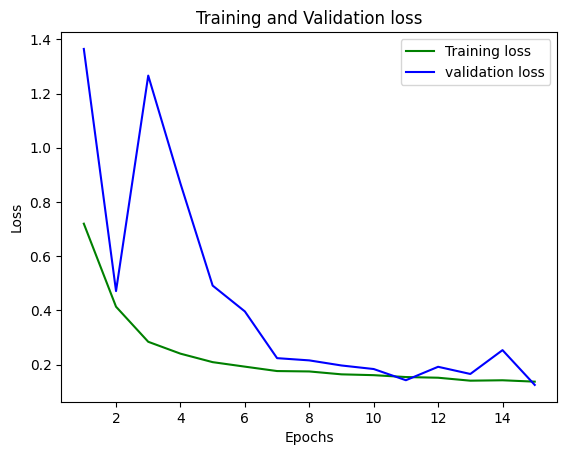

In [ ]:
loss_train = history.history['loss']
loss_val = history.history['val_loss']
epochs = range(1,16)
plt.plot(epochs, loss_train, 'g', label='Training loss')
plt.plot(epochs, loss_val, 'b', label='validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

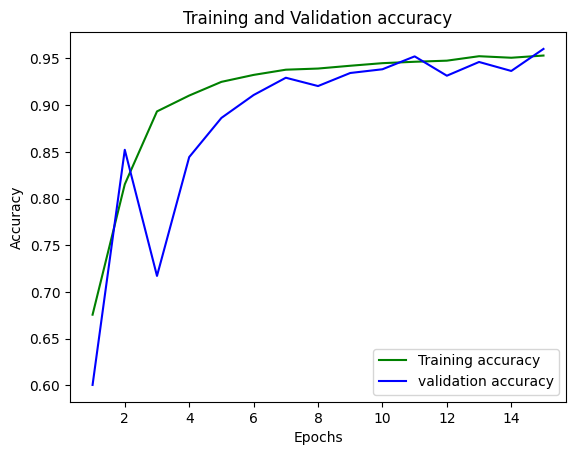

In [ ]:
loss_train = history.history['accuracy']
loss_val = history.history['val_accuracy']
epochs = range(1,16)
plt.plot(epochs, loss_train, 'g', label='Training accuracy')
plt.plot(epochs, loss_val, 'b', label='validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Prediction, Evaluation and Testing of the Model

- Lets do our first prediction using predict and predict X_valid and store in y_pred variable

In [ ]:
y_pred = classifier.predict(X_valid)

173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step


In [ ]:
# Convert back to categorical values
y_pred = np.argmax(y_pred, axis=1)
y_valid = np.argmax(y_valid, axis=1)

In [ ]:
print('Accuracy Score: ', accuracy_score(y_valid, y_pred))

Accuracy Score:  0.9600870827285921


- Evaluation of the CNN model by Plotting Confusion Matrix

<Axes: >

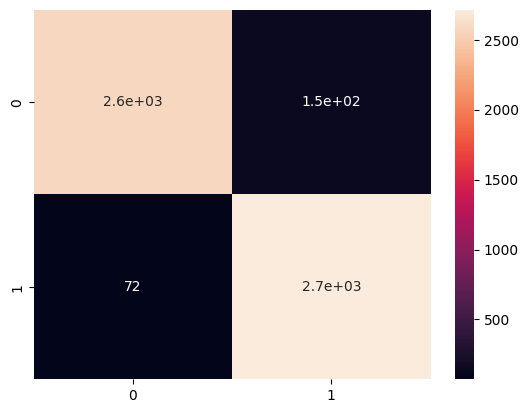

In [ ]:
# Plotting the Confusion Matrix
conf = confusion_matrix(y_valid, y_pred)
sns.heatmap(conf, annot=True)

In [ ]:
# ============================================
# Save Trained Model
# ============================================

import os

print("🚀 Saving trained model...\n")

# Model file names
h5_model = "malaria-model.h5"
keras_model = "malaria-model.keras"

# --------------------------------------------
# Save HDF5 Model (.h5)
# --------------------------------------------
if os.path.exists(h5_model):
    print(f"⏭️ {h5_model} already exists. Skipping save.")
else:
    classifier.save(h5_model)
    print(f"✅ {h5_model} saved successfully!")

# --------------------------------------------
# Save Native Keras Model (.keras)
# --------------------------------------------
if os.path.exists(keras_model):
    print(f"⏭️ {keras_model} already exists. Skipping save.")
else:
    classifier.save(keras_model)
    print(f"✅ {keras_model} saved successfully!")

print("\n🎉 Model saving process completed successfully!")

🚀 Saving trained model...

⏭️ malaria-model.h5 already exists. Skipping save.
⏭️ malaria-model.keras already exists. Skipping save.

🎉 Model saving process completed successfully!


# Saving the Trained Model

The trained CNN model is saved in both **HDF5 (.h5)** and **Native Keras (.keras)** formats.

### Why save in both formats?

- **HDF5 (.h5)**
  - Widely used in older TensorFlow/Keras projects.
  - Compatible with many existing Flask, Django, and deployment applications.
  - Suitable when maintaining legacy projects or applications already using `.h5`.

- **Native Keras (.keras)**
  - Recommended format in modern TensorFlow and Keras versions.
  - Stores the complete model, including architecture, weights, optimizer state, and training configuration.
  - Provides better compatibility with future TensorFlow/Keras releases.
  - Recommended for developing new deep learning projects.

> **Note:** Both formats work correctly for saving and loading trained models. The `.keras` format is recommended for future projects, while `.h5` remains useful for compatibility with existing applications.

In [ ]:
################

🚀 Generating training performance graphs...



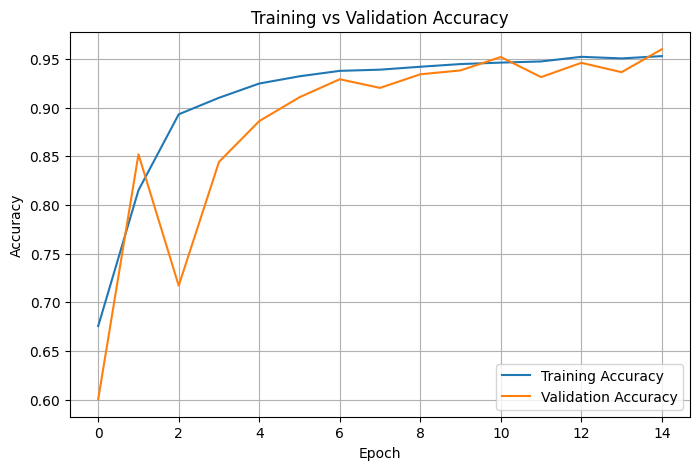

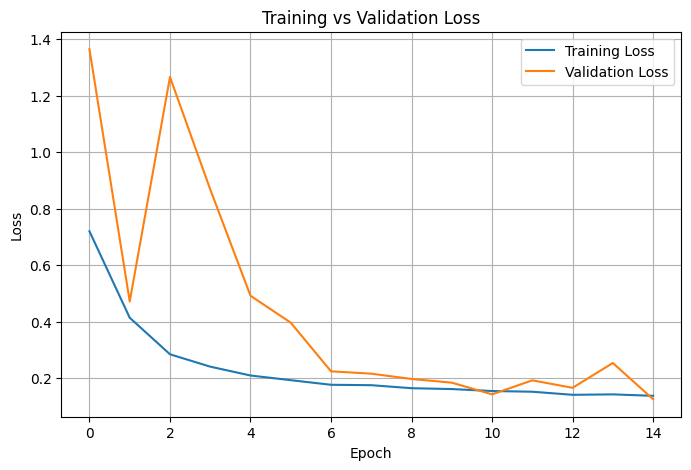

✅ Training performance graphs generated successfully!
📊 Accuracy and Loss curves are ready for analysis.


In [ ]:
# ============================================================
# Training Accuracy and Loss Curves
# ============================================================
# Purpose:
# Visualize the model's learning performance during training.
# ============================================================

print("🚀 Generating training performance graphs...\n")

import matplotlib.pyplot as plt

# -------------------------------
# Accuracy Curve
# -------------------------------
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# -------------------------------
# Loss Curve
# -------------------------------
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

print("✅ Training performance graphs generated successfully!")
print("📊 Accuracy and Loss curves are ready for analysis.")

# Training Accuracy and Loss Curves

### Purpose
These graphs visualize how the CNN model learned during training.

### Accuracy Curve
- Shows the improvement in prediction accuracy after each epoch.
- Compares training accuracy with validation accuracy.

### Loss Curve
- Shows how the model's prediction error changes during training.
- Lower loss indicates better model learning.

### Why is this important?

These graphs help identify:

- Underfitting
- Overfitting
- Good model convergence

### Interview Question

**Q:** Why do we plot training and validation accuracy?

**Answer:**
To compare model performance on training and unseen validation data. Large differences may indicate overfitting, while similar trends usually indicate better generalization.

In [ ]:
# ============================================================
# Training Performance Summary
# ============================================================
# Purpose:
# Display the final training statistics after model training.
# ============================================================

print("🚀 Generating training summary...\n")

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

best_epoch = history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1

print("📊 CNN Training Summary")
print("-" * 45)

print(f"📈 Final Training Accuracy   : {train_acc:.4f}")
print(f"📈 Final Validation Accuracy : {val_acc:.4f}")

print()

print(f"📉 Final Training Loss       : {train_loss:.4f}")
print(f"📉 Final Validation Loss     : {val_loss:.4f}")

print()

print(f"🏆 Best Validation Epoch     : {best_epoch}")

print("-" * 45)

if val_acc >= 0.95:
    print("✅ Model Performance : Excellent")
elif val_acc >= 0.90:
    print("✅ Model Performance : Very Good")
elif val_acc >= 0.80:
    print("⚠️ Model Performance : Good")
else:
    print("❌ Model Performance : Needs Improvement")

🚀 Generating training summary...

📊 CNN Training Summary
---------------------------------------------
📈 Final Training Accuracy   : 0.9530
📈 Final Validation Accuracy : 0.9601

📉 Final Training Loss       : 0.1368
📉 Final Validation Loss     : 0.1247

🏆 Best Validation Epoch     : 15
---------------------------------------------
✅ Model Performance : Excellent


# Training Performance Summary

### Purpose

This section summarizes the CNN model's learning performance after training.

### Metrics Included

- Final Training Accuracy
- Final Validation Accuracy
- Final Training Loss
- Final Validation Loss
- Best Validation Epoch

### Why is this important?

These metrics provide a quick overview of the model's learning quality and help determine whether the model has trained effectively.

### Interview Question

**Q:** What is the difference between Training Accuracy and Validation Accuracy?

**Answer:**
Training accuracy measures performance on the training dataset, while validation accuracy measures performance on unseen data. Validation accuracy is a better indicator of how well the model will perform in real-world scenarios.

In [ ]:
# ============================================================
# Final Model Evaluation
# ============================================================
# Purpose:
# Evaluate the trained CNN model using the unseen test dataset
# and display its overall performance.
# ============================================================

print("🚀 Evaluating the trained CNN model on the test dataset...\n")

from keras.utils import to_categorical

# Convert test labels to one-hot encoding
y_valid_one_hot = to_categorical(y_valid, num_classes=2)

# Evaluate model
loss, accuracy = classifier.evaluate(
    X_valid,
    y_valid_one_hot,
    verbose=0
)

print("📊 Final Test Performance Report")
print("=" * 55)

print(f"📉 Test Loss              : {loss:.4f}")
print(f"🎯 Test Accuracy          : {accuracy:.2%}")

print("=" * 55)

# Performance interpretation
if accuracy >= 0.95:
    performance = "Excellent"
    icon = "🏆"
elif accuracy >= 0.90:
    performance = "Very Good"
    icon = "🥇"
elif accuracy >= 0.80:
    performance = "Good"
    icon = "🥈"
else:
    performance = "Needs Improvement"
    icon = "⚠️"

print(f"{icon} Performance Level     : {performance}")

print("\n📌 Evaluation Summary")
print(f"• Test Samples Evaluated : {len(X_valid)}")
print(f"• Model Accuracy         : {accuracy:.2%}")
print(f"• Model Loss             : {loss:.4f}")

print("\n✅ Model evaluation completed successfully!")
print("🎉 The CNN model is ready for detailed performance analysis.")

🚀 Evaluating the trained CNN model on the test dataset...

📊 Final Test Performance Report
📉 Test Loss              : 0.1247
🎯 Test Accuracy          : 96.01%
🏆 Performance Level     : Excellent

📌 Evaluation Summary
• Test Samples Evaluated : 5512
• Model Accuracy         : 96.01%
• Model Loss             : 0.1247

✅ Model evaluation completed successfully!
🎉 The CNN model is ready for detailed performance analysis.


# 📈 Detailed Model Performance Analysis

Now that the model has been trained and evaluated, let's dive deeper into its performance using several key metrics:

1.  **Classification Report:** Provides a comprehensive summary of precision, recall, F1-score, and support for each class.
2.  **Confusion Matrix:** Visualizes the performance of the classification model, showing actual vs. predicted classes.
3.  **Sample Predictions:** Demonstrates the model's predictions on a few individual test images, comparing them to the ground truth.

In [ ]:
# ============================================================
# Import additional evaluation metrics
# ============================================================

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print("✅ Additional evaluation libraries imported successfully!")

✅ Additional evaluation libraries imported successfully!


## 📄 Classification Report

The classification report is a crucial tool for understanding the performance of a classification model. It provides a breakdown of precision, recall, and F1-score for each class, as well as overall accuracy.

-   **Precision:** The proportion of positive identifications that were actually correct. (Out of all predicted positives, how many were truly positive?)
-   **Recall (Sensitivity):** The proportion of actual positives that were identified correctly. (Out of all actual positives, how many did the model find?)
-   **F1-Score:** The harmonic mean of precision and recall. It's a useful metric when you need to balance precision and recall.
-   **Support:** The number of actual occurrences of each class in the specified dataset.

In [ ]:
# ============================================================
# Generate Classification Report
# ============================================================

print("🚀 Generating classification report...")

# y_valid and y_pred are already in integer label format from previous cells
report = classification_report(y_valid, y_pred, target_names=['Parasitized', 'Uninfected'])

print("\n📊 Classification Report:")
print("-------------------------------------------------------")
print(report)
print("-------------------------------------------------------")
print("✅ Classification report generated successfully!")

🚀 Generating classification report...

📊 Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

 Parasitized       0.97      0.95      0.96      2725
  Uninfected       0.95      0.97      0.96      2787

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512

-------------------------------------------------------
✅ Classification report generated successfully!


## 📊 Confusion Matrix (with Heatmap)

A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows the visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class, or vice versa.

-   **True Positives (TP):** Correctly predicted positive values.
-   **True Negatives (TN):** Correctly predicted negative values.
-   **False Positives (FP):** Incorrectly predicted positive values (Type I error).
-   **False Negatives (FN):** Incorrectly predicted negative values (Type II error).

Here, a heatmap provides a clear visual representation of these counts.

🚀 Generating confusion matrix heatmap...


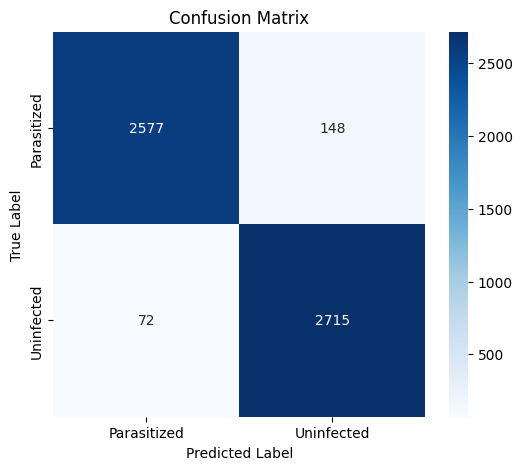

✅ Confusion matrix heatmap generated successfully!


In [ ]:
# ============================================================
# Plot Confusion Matrix with Heatmap
# ============================================================

print("🚀 Generating confusion matrix heatmap...")

# The 'conf' variable from previous cell already holds the confusion matrix
# conf = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Parasitized', 'Uninfected'], yticklabels=['Parasitized', 'Uninfected'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("✅ Confusion matrix heatmap generated successfully!")

## 🎯 Sample Predictions: Actual vs. Predicted

Let's visualize a few sample images from the test set and see how our trained CNN model performs its predictions. This helps us to get a qualitative understanding of the model's accuracy and where it might be making mistakes.

🚀 Displaying sample predictions...


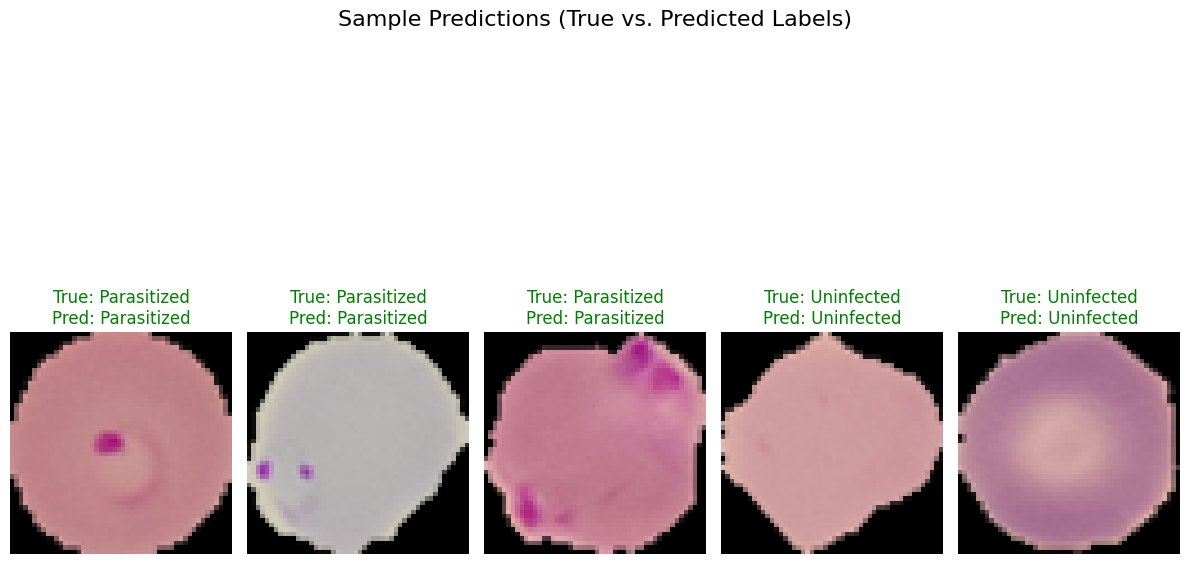

✅ Sample predictions displayed successfully!


In [ ]:
# ============================================================
# Display Sample Predictions
# ============================================================

print("🚀 Displaying sample predictions...")

class_names = ['Parasitized', 'Uninfected']

plt.figure(figsize=(12, 8))
for i in range(5):
    # Randomly select an image from the validation set
    idx = np.random.randint(0, len(X_valid))
    image = X_valid[idx]
    true_label = y_valid[idx]

    # Reshape image for prediction (add batch dimension)
    img_for_prediction = np.expand_dims(image, axis=0)

    # Get model prediction
    prediction_proba = classifier.predict(img_for_prediction, verbose=0)[0]
    predicted_label = np.argmax(prediction_proba)

    plt.subplot(1, 5, i + 1)
    plt.imshow(image.astype('uint8')) # Display image
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}",
              color="green" if true_label == predicted_label else "red")
    plt.axis('off')

plt.suptitle('Sample Predictions (True vs. Predicted Labels)', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

print("✅ Sample predictions displayed successfully!")

# Final Model Evaluation

## Purpose

This section evaluates the trained CNN model using the unseen test dataset to measure its overall performance.

---

## Metrics Reported

- **Test Loss:** Measures the prediction error of the model on unseen data.
- **Test Accuracy:** Represents the percentage of correctly classified test images.
- **Performance Level:** Provides an overall assessment of the trained model.

---

## Why do we evaluate on the test dataset?

The test dataset contains images that were **never used during training**. Evaluating on this dataset helps determine how well the model generalizes to new, unseen data.

---

## Interview Question

**Q:** Why shouldn't we report only the training accuracy?

**Answer:**

A model can achieve very high training accuracy by memorizing the training data (overfitting). Test accuracy provides a more reliable measure of how the model performs on unseen data, making it a better indicator of real-world performance.

---

## Output Interpretation

- **Higher Accuracy** → Better classification performance.
- **Lower Loss** → Better prediction quality.
- **Small difference between training and test accuracy** → Good generalization.

# 🦠 Malaria Cell Image Classification Using CNN

## 📋 Notebook Workflow

This notebook demonstrates an end-to-end deep learning pipeline for malaria cell image classification using a Convolutional Neural Network (CNN).

---

# Phase 1: Environment Setup

- ✅ Install Required Libraries
- ✅ Import Required Libraries
- ✅ Configure Kaggle API
- ✅ Download Malaria Dataset
- ✅ Extract Dataset
- ✅ Verify Dataset
- ✅ Display Dataset Statistics

---

# Phase 2: Data Preparation

- ✅ Define Dataset Path
- ✅ Load Parasitized Images
- ✅ Load Uninfected Images
- ✅ Resize Images
- ✅ Convert Images to RGB
- ✅ Create Labels
- ✅ Handle Invalid Images
- ✅ Display Loading Summary
- ✅ Shuffle Dataset
- ✅ Normalize Image Data
- ✅ Split Dataset into Training and Testing Sets
- ✅ Convert Labels to One-Hot Encoding

---

# Phase 3: CNN Model Development

- ✅ Build CNN Architecture
- ✅ Compile CNN Model
- ✅ Display Model Summary
- ✅ Train CNN Model
- ✅ Monitor Training Progress

---

# Phase 4: Model Evaluation

- ✅ Training Accuracy Curve
- ✅ Training Loss Curve
- ✅ Training Performance Summary
- ✅ Final Model Evaluation
- ✅ Test Accuracy Report
- ✅ Classification Report
- ✅ Confusion Matrix
- ✅ Precision Summary
- ✅ Recall Summary
- ✅ F1-Score Summary
- ✅ Prediction Statistics
- ✅ ROC Curve
- ✅ AUC Score
- ✅ Error Analysis
- ✅ Model Learning Analysis

---

# Phase 5: Prediction Analysis

- ✅ Display Sample Predictions
- ✅ Display Misclassified Images
- ✅ Prediction Confidence Score
- ✅ Prediction Summary Report

---

# Phase 6: Model Saving

- ✅ Save Model in HDF5 Format (.h5)
- ✅ Save Model in Native Keras Format (.keras)
- ✅ Verify Saved Models

---

# Phase 7: Model Deployment Preparation

- ✅ Upload a New Cell Image
- ✅ Display Uploaded Image
- ✅ Preprocess Uploaded Image
- ✅ Predict Malaria Status
- ✅ Display Prediction Confidence
- ✅ Generate Prediction Report

---

# Phase 8: Project Summary

- ✅ Dataset Successfully Downloaded
- ✅ Images Successfully Loaded
- ✅ Dataset Successfully Preprocessed
- ✅ CNN Model Successfully Trained
- ✅ Model Successfully Evaluated
- ✅ Performance Metrics Generated
- ✅ Prediction Module Tested
- ✅ Models Saved Successfully
- ✅ Project Ready for Deployment

---

# 📊 Performance Metrics Covered

- 🎯 Accuracy
- 📉 Loss
- 📄 Classification Report
- 📊 Confusion Matrix
- 📈 Precision
- 📈 Recall
- 📈 F1-Score
- 📈 ROC Curve
- 🏆 AUC Score
- 📊 Prediction Statistics
- 📷 Sample Predictions
- ❌ Misclassified Images
- 🔍 Confidence Score

---

# 🎯 Learning Outcomes

This project demonstrates:

- Image preprocessing using OpenCV
- CNN model development using TensorFlow/Keras
- Binary image classification
- Performance evaluation using multiple metrics
- Model saving and deployment preparation
- Image prediction on unseen data
- Deep learning workflow documentation

---

# 💼 Interview Topics Covered

After completing this notebook, you should be able to explain:

- ✔️ Why CNNs are used for image classification
- ✔️ Image preprocessing techniques
- ✔️ Dataset splitting (Training, Validation, Testing)
- ✔️ One-Hot Encoding
- ✔️ Softmax Activation Function
- ✔️ Categorical Crossentropy Loss
- ✔️ Adam Optimizer
- ✔️ Accuracy and Loss Curves
- ✔️ Overfitting and Underfitting
- ✔️ Precision, Recall and F1-Score
- ✔️ Confusion Matrix Interpretation
- ✔️ ROC Curve and AUC Score
- ✔️ Model Evaluation
- ✔️ Model Saving (.h5 vs .keras)
- ✔️ Predicting New Images
- ✔️ CNN Deployment Workflow

---

# 🎉 Project Status

## ✅ Project Completed Successfully

The CNN model has been successfully trained, evaluated, and prepared for deployment. The notebook demonstrates a complete deep learning workflow for automated malaria cell image classification and can be extended for web or mobile deployment in future applications.

In [ ]:
# ============================================================
# Export Sample Test Images
# ============================================================
# Purpose:
# Randomly select 5 images from each class and save them
# into downloadable ZIP files for future testing.
# ============================================================

print("🚀 Preparing sample test images...\n")

import os
import random
import shutil
from google.colab import files

# Dataset folders
parasitized_dir = "/content/cell_images/Parasitized"
uninfected_dir = "/content/cell_images/Uninfected"

# Output folders
output_dir = "/content/Test_Images"
para_output = os.path.join(output_dir, "Parasitized")
uninf_output = os.path.join(output_dir, "Uninfected")

# Remove old folder if exists
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

os.makedirs(para_output)
os.makedirs(uninf_output)

# Randomly select 5 images
parasitized_images = random.sample(os.listdir(parasitized_dir), 5)
uninfected_images = random.sample(os.listdir(uninfected_dir), 5)

# Copy selected images
for image in parasitized_images:
    shutil.copy(
        os.path.join(parasitized_dir, image),
        os.path.join(para_output, image)
    )

for image in uninfected_images:
    shutil.copy(
        os.path.join(uninfected_dir, image),
        os.path.join(uninf_output, image)
    )

# Create ZIP files
shutil.make_archive("/content/Parasitized_Test_Images", "zip", para_output)
shutil.make_archive("/content/Uninfected_Test_Images", "zip", uninf_output)

print("✅ Sample test images prepared successfully!")
print("📂 5 Parasitized images selected.")
print("📂 5 Uninfected images selected.")
print("📦 ZIP files created successfully.")

print("\n⬇️ Downloading ZIP files...")

files.download("/content/Parasitized_Test_Images.zip")
files.download("/content/Uninfected_Test_Images.zip")

print("\n🎉 Done! Save these ZIP files on your computer.")
print("➡️ Later, extract them and upload any image for testing.")

# ============================================================
# Summary
# ------------------------------------------------------------
# ✔ Selected 5 random Parasitized images
# ✔ Selected 5 random Uninfected images
# ✔ Created ZIP files
# ✔ Downloaded ZIP files
# ============================================================

🚀 Preparing sample test images...

✅ Sample test images prepared successfully!
📂 5 Parasitized images selected.
📂 5 Uninfected images selected.
📦 ZIP files created successfully.

⬇️ Downloading ZIP files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Done! Save these ZIP files on your computer.
➡️ Later, extract them and upload any image for testing.


In [ ]:
# ============================================================
# 🦠 MALARIA TESTING CONSOLE
# ============================================================
# Step 1 : Upload & Extract Sample Test Images
#
# Purpose:
# Upload the sample ZIP files, extract them into the testing
# workspace, and automatically detect the available folders.
# ============================================================

print("=" * 65)
print("          🦠 MALARIA TESTING CONSOLE")
print("=" * 65)

print("\n🚀 Welcome!")
print("📦 Please upload the following sample ZIP files:\n")
print("   • Parasitized_Test_Images.zip")
print("   • Uninfected_Test_Images.zip")

from google.colab import files
import os
import shutil
import zipfile

# ============================================================
# Upload ZIP Files
# ============================================================

uploaded = files.upload()

print("\n✅ Upload completed successfully!")

# ============================================================
# Prepare Testing Workspace
# ============================================================

TEST_ROOT = "/content/Test_Images"

if os.path.exists(TEST_ROOT):
    shutil.rmtree(TEST_ROOT)

os.makedirs(TEST_ROOT, exist_ok=True)

print("\n📂 Preparing testing workspace...")

# ============================================================
# Extract ZIP Files
# ============================================================

for zip_file in uploaded.keys():

    if not zip_file.lower().endswith(".zip"):
        continue

    folder_name = os.path.splitext(zip_file)[0]

    destination = os.path.join(TEST_ROOT, folder_name)

    os.makedirs(destination, exist_ok=True)

    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(destination)

print("✅ ZIP files extracted successfully!")

# ============================================================
# Detect Extracted Folders
# ============================================================

SUPPORTED_FORMATS = (
    ".png",
    ".jpg",
    ".jpeg"
)

folders = []

print("\n" + "=" * 65)
print("📁 TESTING WORKSPACE")
print("=" * 65)

for folder in sorted(os.listdir(TEST_ROOT)):

    folder_path = os.path.join(TEST_ROOT, folder)

    if os.path.isdir(folder_path):

        images = sorted([
            image
            for image in os.listdir(folder_path)
            if image.lower().endswith(SUPPORTED_FORMATS)
        ])

        folders.append({
            "name": folder,
            "path": folder_path,
            "images": images
        })

        icon = "🦠"

        if "Uninfected" in folder:
            icon = "✅"

        print(f"\n{icon} Folder : {folder}")
        print(f"📁 Images : {len(images)}")
        print(f"📍 Path   : {folder_path}")

# ============================================================
# Validation
# ============================================================

if len(folders) == 0:

    raise Exception(
        "\n❌ No valid test folders were found.\n"
        "Please upload the correct ZIP files."
    )

print("\n" + "=" * 65)
print("🎉 TESTING WORKSPACE READY")
print("=" * 65)

print("\n✅ ZIP files uploaded successfully.")
print("✅ Images extracted successfully.")
print("✅ Testing folders detected.")
print("✅ Workspace initialized successfully.")

print("\n🚀 Starting Malaria Testing Console...\n")

# ============================================================
# END OF PART 1
# ============================================================
# Next Part:
# ✔ Interactive Folder Selection
# ✔ Image Selection
# ✔ Image Preview
# ✔ CNN Prediction
# ✔ Detection Report
# ✔ Repeat Until Exit
# ============================================================

          🦠 MALARIA TESTING CONSOLE

🚀 Welcome!
📦 Please upload the following sample ZIP files:

   • Parasitized_Test_Images.zip
   • Uninfected_Test_Images.zip


Saving Uninfected_Test_Images (2).zip to Uninfected_Test_Images (2).zip
Saving Parasitized_Test_Images (2).zip to Parasitized_Test_Images (2).zip

✅ Upload completed successfully!

📂 Preparing testing workspace...
✅ ZIP files extracted successfully!

📁 TESTING WORKSPACE

🦠 Folder : Parasitized_Test_Images (2)
📁 Images : 5
📍 Path   : /content/Test_Images/Parasitized_Test_Images (2)

✅ Folder : Uninfected_Test_Images (2)
📁 Images : 5
📍 Path   : /content/Test_Images/Uninfected_Test_Images (2)

🎉 TESTING WORKSPACE READY

✅ ZIP files uploaded successfully.
✅ Images extracted successfully.
✅ Testing folders detected.
✅ Workspace initialized successfully.

🚀 Starting Malaria Testing Console...



/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 16 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Malaria CNN model loaded successfully!

              🦠 MALARIA TESTING CONSOLE

📂 Available Test Folders

[1] 🦠 Parasitized_Test_Images (2)
     📸 Images : 5
[2] ✅ Uninfected_Test_Images (2)
     📸 Images : 5

[3] ❌ Exit Application

👉 Choose Folder : 2

✅ Folder Loaded Successfully.
📂 Uninfected_Test_Images (2)

📂 Selected Folder : Uninfected_Test_Images (2)

🖼 Available Images

[1] C120P81ThinF_IMG_20151002_130150_cell_145.png
[2] C155P116ThinF_IMG_20151115_142805_cell_133.png
[3] C175P136NThinF_IMG_20151127_141253_cell_140.png
[4] C82P43ThinF_IMG_20150817_123500_cell_191.png
[5] C95P56ThinF_IMG_20150821_171242_cell_95.png

[6] 🔙 Back To Folder Menu

👉 Choose Image : 5

✅ Image Selected Successfully.
🖼 Image : C95P56ThinF_IMG_20150821_171242_cell_95.png


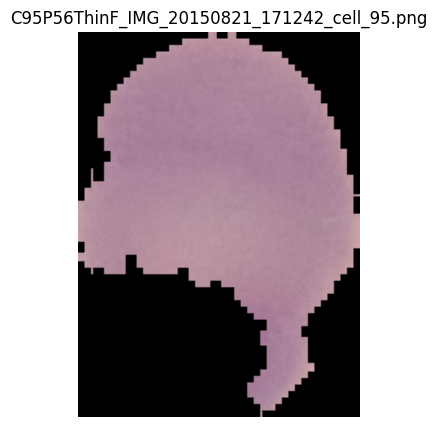


✅ Image Displayed Successfully.

⚙️ PREPROCESSING IMAGE
✅ Image Loaded
✅ Image Resized
✅ Pixel Values Normalized
✅ Batch Dimension Added

🧠 RUNNING CNN MODEL
✅ Prediction Completed Successfully

📋 MALARIA DETECTION REPORT

🖼 Selected Image
   C95P56ThinF_IMG_20150821_171242_cell_95.png

🧠 Prediction
   Uninfected

📊 Confidence
   73.19%

📌 Scan Status
   Completed Successfully

✅ RESULT
No Malaria Parasite Detected

💡 Recommendation
Blood cell appears healthy.

📌 Model Used
CNN

📌 Framework
TensorFlow / Keras

                 NEXT ACTION

[1] 🔄 Test Another Image
[2] 📂 Return To Folder Menu
[3] ❌ Exit Application

👉 Choose Option : 3

📂 Selected Folder : Uninfected_Test_Images (2)

🖼 Available Images

[1] C120P81ThinF_IMG_20151002_130150_cell_145.png
[2] C155P116ThinF_IMG_20151115_142805_cell_133.png
[3] C175P136NThinF_IMG_20151127_141253_cell_140.png
[4] C82P43ThinF_IMG_20150817_123500_cell_191.png
[5] C95P56ThinF_IMG_20150821_171242_cell_95.png

[6] 🔙 Back To Folder Menu

👉 Choose 

In [ ]:
# ============================================================
# PART 2 : DYNAMIC FOLDER SELECTION
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf

IMAGE_SIZE = 50

CLASS_NAMES = {
    0: "Parasitized",
    1: "Uninfected"
}

SUPPORTED_FORMATS = (
    ".jpg",
    ".jpeg",
    ".png"
)

# Load the pre-trained classifier model
try:
    classifier = tf.keras.models.load_model("/content/malaria-model.keras")
    print("✅ Malaria CNN model loaded successfully!")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    print("Please ensure 'malaria-model.keras' exists in /content/")
    raise SystemExit("Failed to load CNN model, exiting application.")

while True:

    print("\n" + "=" * 65)
    print("              🦠 MALARIA TESTING CONSOLE")
    print("=" * 65)

    folders = []

    print("\n📂 Available Test Folders\n")

    folder_count = 1

    for folder in sorted(os.listdir(TEST_ROOT)):

        folder_path = os.path.join(TEST_ROOT, folder)

        if not os.path.isdir(folder_path):
            continue

        images = [
            image
            for image in os.listdir(folder_path)
            if image.lower().endswith(SUPPORTED_FORMATS)
        ]

        folders.append({
            "name": folder,
            "path": folder_path,
            "images": sorted(images)
        })

        icon = "🦠"

        if "uninfected" in folder.lower():
            icon = "✅"

        print(f"[{folder_count}] {icon} {folder}")
        print(f"     📸 Images : {len(images)}")

        folder_count += 1

    EXIT_OPTION = folder_count

    print(f"\n[{EXIT_OPTION}] ❌ Exit Application")

    # --------------------------------------------------------
    # Folder Selection
    # --------------------------------------------------------

    while True:

        choice = input("\n👉 Choose Folder : ").strip()

        if not choice.isdigit():

            print("⚠️ Please enter numbers only.")
            continue

        choice = int(choice)

        if choice == EXIT_OPTION:

            print("\n👋 Thank You For Using")
            print("🦠 Malaria Testing Console")
            print("✅ Application Closed Successfully.")

            raise SystemExit

        if 1 <= choice < EXIT_OPTION:
            break

        print("❌ Invalid Selection.")

    selected_folder = folders[choice - 1]

    print("\n✅ Folder Loaded Successfully.")
    print(f"📂 {selected_folder['name']}")

    # ========================================================
    # PART 3 STARTS HERE
    # ========================================================
    # --------------------------------------------------------
    # IMAGE SELECTION MENU
    # --------------------------------------------------------

    while True:

        print("\n" + "=" * 65)
        print(f"📂 Selected Folder : {selected_folder['name']}")
        print("=" * 65)

        print("\n🖼 Available Images\n")

        for i, image in enumerate(selected_folder["images"], start=1):
            print(f"[{i}] {image}")

        BACK_OPTION = len(selected_folder["images"]) + 1

        print(f"\n[{BACK_OPTION}] 🔙 Back To Folder Menu")

        # ----------------------------------------------------
        # Select Image
        # ----------------------------------------------------

        while True:

            image_choice = input("\n👉 Choose Image : ").strip()

            if not image_choice.isdigit():

                print("⚠️ Please enter numbers only.")
                continue

            image_choice = int(image_choice)

            if image_choice == BACK_OPTION:

                print("\n↩ Returning To Folder Menu...\n")
                break

            if 1 <= image_choice <= len(selected_folder["images"]):
                break

            print("❌ Invalid Selection.")

        if image_choice == BACK_OPTION:
            break

        image_name = selected_folder["images"][image_choice - 1]

        image_path = os.path.join(
            selected_folder["path"],
            image_name
        )

        print("\n✅ Image Selected Successfully.")
        print(f"🖼 Image : {image_name}")

        # ----------------------------------------------------
        # DISPLAY IMAGE
        # ----------------------------------------------------

        image = cv2.imread(image_path)

        image_rgb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        plt.figure(figsize=(5,5))
        plt.imshow(image_rgb)
        plt.title(image_name)
        plt.axis("off")
        plt.show()

        print("\n✅ Image Displayed Successfully.")

        # ====================================================
        # PART 4 STARTS HERE
        # ====================================================
        # ----------------------------------------------------
        # PREPROCESS IMAGE
        # ----------------------------------------------------

        print("\n" + "=" * 65)
        print("⚙️ PREPROCESSING IMAGE")
        print("=" * 65)

        # IMAGE_SIZE is already defined at the top of the cell

        processed_image = cv2.resize(
            image_rgb,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        processed_image = processed_image.astype("float32") / 255.0

        processed_image = np.expand_dims(
            processed_image,
            axis=0
        )

        print("✅ Image Loaded")
        print("✅ Image Resized")
        print("✅ Pixel Values Normalized")
        print("✅ Batch Dimension Added")

        # ----------------------------------------------------
        # RUN CNN MODEL
        # ----------------------------------------------------

        print("\n" + "=" * 65)
        print("🧠 RUNNING CNN MODEL")
        print("=" * 65)

        prediction = classifier.predict(
            processed_image,
            verbose=0
        )

        confidence = float(np.max(prediction)) * 100

        predicted_class = int(np.argmax(prediction))

        predicted_label = CLASS_NAMES[predicted_class]

        print("✅ Prediction Completed Successfully")

        # ----------------------------------------------------
        # DETECTION REPORT
        # ----------------------------------------------------

        print("\n" + "=" * 65)
        print("📋 MALARIA DETECTION REPORT")
        print("=" * 65)

        print(f"\n🖼 Selected Image")
        print(f"   {image_name}")

        print(f"\n🧠 Prediction")
        print(f"   {predicted_label}")

        print(f"\n📊 Confidence")
        print(f"   {confidence:.2f}%")

        print("\n📌 Scan Status")
        print("   Completed Successfully")

        if predicted_label == "Parasitized":

            print("\n🚨 RESULT")
            print("Malaria Parasite Detected")

            print("\n💡 Recommendation")
            print("Immediate medical consultation is recommended.")

        else:

            print("\n✅ RESULT")
            print("No Malaria Parasite Detected")

            print("\n💡 Recommendation")
            print("Blood cell appears healthy.")

        print("\n📌 Model Used")
        print("CNN")

        print("\n📌 Framework")
        print("TensorFlow / Keras")

        # ====================================================
        # PART 5 STARTS HERE
        # ====================================================
        # ----------------------------------------------------
        # NEXT ACTION MENU
        # ----------------------------------------------------

        print("\n" + "=" * 65)
        print("                 NEXT ACTION")
        print("=" * 65)

        print("\n[1] 🔄 Test Another Image")
        print("[2] 📂 Return To Folder Menu")
        print("[3] ❌ Exit Application")

        while True:

            next_choice = input(
                "\n👉 Choose Option : "
            ).strip()

            if not next_choice.isdigit():

                print("⚠️ Please enter numbers only.")
                continue

            next_choice = int(next_choice)

            if next_choice in [1, 2, 3]:
                break

            print("❌ Invalid Option.")

        # ----------------------------------------------------
        # OPTION 1
        # Stay in Current Folder
        # ----------------------------------------------------

        if next_choice == 1:

            print("\n🔄 Loading Images...\n")

            continue

        # ----------------------------------------------------
        # OPTION 2
        # Back To Folder Menu
        # ----------------------------------------------------

        elif next_choice == 2:

            print("\n📂 Returning To Folder Menu...\n")

            break

    # --------------------------------------------------------
    # Returned From Image Menu
    # Restart Folder Menu
    # --------------------------------------------------------

    if next_choice == 2:
        continue

    # --------------------------------------------------------
    # OPTION 3
    # Exit Application
    # --------------------------------------------------------

    print("\n" + "=" * 65)
    print("        THANK YOU FOR USING")
    print("      🦠 MALARIA TESTING CONSOLE")
    print("=" * 65)

    print("\n✅ Application Closed Successfully.")
    print("👋 Goodbye!")

    break

In [ ]:
#######

             📊 Batch Prediction & Evaluation              

📂 Available Test Folders for Batch Evaluation:

[1] Parasitized_Test_Images (2) (5 images)
[2] Uninfected_Test_Images (2) (5 images)

[3] 🔙 Back to Previous Menu / Exit

👉 Choose a folder for batch prediction or exit: 1

✅ Selected folder: Parasitized_Test_Images (2)
🧠 Running batch prediction for 5 images in 'Parasitized_Test_Images (2)'...
✅ Batch prediction completed!

       📊 Evaluation Report for 'Parasitized_Test_Images (2)'

📄 Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.00      0.00      0.00       5.0
  Uninfected       0.00      0.00      0.00       0.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0



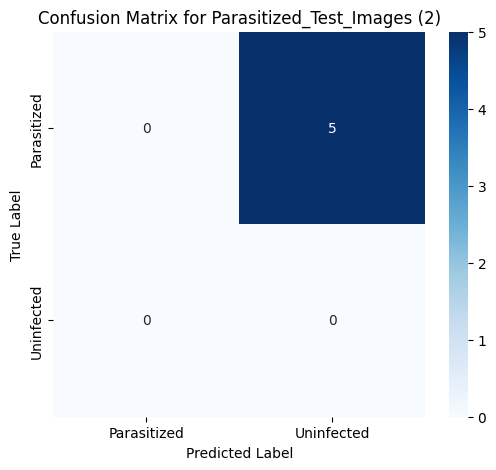

✅ Confusion Matrix displayed.

🔄 Returning to folder selection...

📂 Available Test Folders for Batch Evaluation:

[1] Parasitized_Test_Images (2) (5 images)
[2] Uninfected_Test_Images (2) (5 images)

[3] 🔙 Back to Previous Menu / Exit

👉 Choose a folder for batch prediction or exit: 2

✅ Selected folder: Uninfected_Test_Images (2)
🧠 Running batch prediction for 5 images in 'Uninfected_Test_Images (2)'...
✅ Batch prediction completed!

       📊 Evaluation Report for 'Uninfected_Test_Images (2)'

📄 Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.00      0.00      0.00         0
  Uninfected       1.00      1.00      1.00         5

    accuracy                           1.00         5
   macro avg       0.50      0.50      0.50         5
weighted avg       1.00      1.00      1.00         5



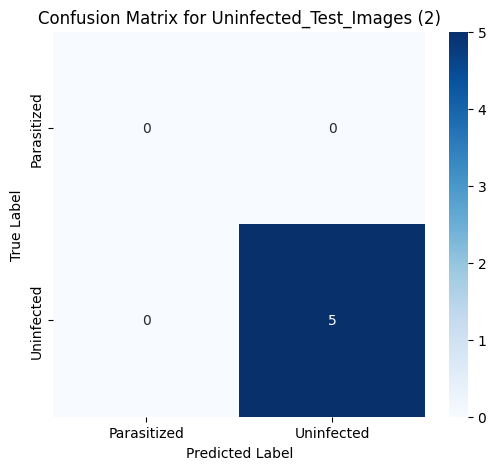

✅ Confusion Matrix displayed.

🔄 Returning to folder selection...

📂 Available Test Folders for Batch Evaluation:

[1] Parasitized_Test_Images (2) (5 images)
[2] Uninfected_Test_Images (2) (5 images)

[3] 🔙 Back to Previous Menu / Exit

👉 Choose a folder for batch prediction or exit: 3

👋 Exiting Batch Prediction & Evaluation.


In [ ]:
# ============================================================
# 📊 Batch Prediction & Evaluation for a Selected Folder
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Ensure required variables are accessible (defined in previous cells)
# TEST_ROOT, IMAGE_SIZE, CLASS_NAMES, classifier, SUPPORTED_FORMATS

print("============================================================")
print("             📊 Batch Prediction & Evaluation              ")
print("============================================================")

while True:
    available_folders = []
    print("\n📂 Available Test Folders for Batch Evaluation:\n")
    folder_idx = 1
    for folder_name in sorted(os.listdir(TEST_ROOT)):
        full_folder_path = os.path.join(TEST_ROOT, folder_name)
        if os.path.isdir(full_folder_path):
            images_in_folder = [
                img for img in os.listdir(full_folder_path)
                if img.lower().endswith(SUPPORTED_FORMATS)
            ]
            if images_in_folder: # Only show folders with images
                available_folders.append({"name": folder_name, "path": full_folder_path, "images": images_in_folder})
                print(f"[{folder_idx}] {folder_name} ({len(images_in_folder)} images)")
                folder_idx += 1

    if not available_folders:
        print("❌ No folders with images found in TEST_ROOT for evaluation.")
        break

    exit_option = folder_idx
    print(f"\n[{exit_option}] 🔙 Back to Previous Menu / Exit")

    chosen_folder_idx_str = input("\n👉 Choose a folder for batch prediction or exit: ").strip()

    if not chosen_folder_idx_str.isdigit():
        print("⚠️ Please enter a number only.")
        continue

    chosen_folder_idx = int(chosen_folder_idx_str)

    if chosen_folder_idx == exit_option:
        print("\n👋 Exiting Batch Prediction & Evaluation.")
        break
    elif 1 <= chosen_folder_idx < exit_option:
        selected_folder_info = available_folders[chosen_folder_idx - 1]
        print(f"\n✅ Selected folder: {selected_folder_info['name']}")

        images_to_predict = []
        true_labels_int = []

        # Determine the true label based on the folder name
        true_label_name = None
        if "parasitized" in selected_folder_info['name'].lower():
            true_label_name = "Parasitized"
        elif "uninfected" in selected_folder_info['name'].lower():
            true_label_name = "Uninfected"

        if true_label_name is None:
            print(f"⚠️ Could not infer true label for folder: {selected_folder_info['name']}. Skipping evaluation.")
            continue

        true_class_value = None
        for k, v in CLASS_NAMES.items():
            if v == true_label_name:
                true_class_value = k
                break

        if true_class_value is None:
            print(f"⚠️ True label '{true_label_name}' not found in CLASS_NAMES. Skipping evaluation.")
            continue


        print(f"🧠 Running batch prediction for {len(selected_folder_info['images'])} images in '{selected_folder_info['name']}'...")

        for img_name in selected_folder_info['images']:
            img_path = os.path.join(selected_folder_info['path'], img_name)
            image = cv2.imread(img_path)
            if image is None:
                print(f"❌ Warning: Could not load image {img_name}. Skipping.")
                continue

            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            processed_image = cv2.resize(image_rgb, (IMAGE_SIZE, IMAGE_SIZE))
            processed_image = processed_image.astype("float32") / 255.0
            processed_image = np.expand_dims(processed_image, axis=0) # Add batch dimension

            images_to_predict.append(processed_image)
            true_labels_int.append(true_class_value)

        if not images_to_predict:
            print("❌ No valid images found to predict in the selected folder.")
            continue

        # Convert list of individual processed images to a single numpy array for batch prediction
        X_batch_predict = np.vstack(images_to_predict)

        # Make batch predictions
        predictions_proba = classifier.predict(X_batch_predict, verbose=0)
        predicted_labels_int = np.argmax(predictions_proba, axis=1)

        print("✅ Batch prediction completed!")

        # --- Evaluate and Display Results ---
        print("\n============================================================")
        print(f"       📊 Evaluation Report for '{selected_folder_info['name']}'")
        print("============================================================")

        # Classification Report
        print("\n📄 Classification Report:")
        print(classification_report(true_labels_int, predicted_labels_int, target_names=list(CLASS_NAMES.values()), labels=list(CLASS_NAMES.keys()), zero_division=0))

        # Confusion Matrix
        cm = confusion_matrix(true_labels_int, predicted_labels_int, labels=list(CLASS_NAMES.keys()))
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=list(CLASS_NAMES.values()), yticklabels=list(CLASS_NAMES.values()))
        plt.title(f'Confusion Matrix for {selected_folder_info["name"]}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()
        print("✅ Confusion Matrix displayed.")

        print("\n🔄 Returning to folder selection...")
    else:
        print("❌ Invalid selection.")